# ABSA E-Commerce Indonesia — IndoBERT Fine-Tuning
**Aspect-Based Sentiment Analysis** pada Ulasan Google Play Store

- Dataset  : Tokopedia, Bukalapak, Blibli (rating 1–2 bintang)
- Labeling : Rule-Based (keyword dictionary per aspek)
- Model    : Baseline TF-IDF+LR | IndoBERT-Base | IndoBERT-Large

---
**Alur:**
1. Konfigurasi Global
2. Install & Import
3. Load & Filter Dataset (Tokopedia, Bukalapak, Blibli — rating 1–2)
4. Preprocessing
5. EDA (Exploratory Data Analysis)
6. Labeling Aspek Rule-Based
7. Tokenisasi & Split Dataset
8. Baseline: TF-IDF + Logistic Regression
9. Fine-Tuning IndoBERT-Base
10. Fine-Tuning IndoBERT-Large
11. Evaluasi & Perbandingan Model
12. Simpan Model
13. Inference Test

## 1. Konfigurasi Global

In [1]:
# KONFIGURASI GLOBAL
DATASET_FILES = {
    'tokopedia': 'tokopedia.csv',
    'bukalapak': 'bukalapak.csv',
    'blibli'   : 'blibli.csv'
}

DATASET_PATH = '/kaggle/input/datasets/rezkyyayang/reviews-of-indonesian-app-startups-on-playstore'
OUTPUT_PATH  = '/kaggle/working'

# Jumlah sampel untuk training
ANNOTATION_SAMPLE = None

# Hyperparameter training
LEARNING_RATE    = 2e-5
BATCH_SIZE_BASE  = 16
BATCH_SIZE_LARGE = 8
EPOCHS           = 3
MAX_SEQ_LENGTH   = 128
SEED             = 42

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)

print('Konfigurasi berhasil dimuat')
print(f'  Dataset path      : {DATASET_PATH}')
print(f'  Output path       : {OUTPUT_PATH}')
print(f'  Annotation sample : {ANNOTATION_SAMPLE}')
print(f'  Epochs            : {EPOCHS}')
print(f'  Max seq length    : {MAX_SEQ_LENGTH}')

Konfigurasi berhasil dimuat
  Dataset path      : /kaggle/input/datasets/rezkyyayang/reviews-of-indonesian-app-startups-on-playstore
  Output path       : /kaggle/working
  Annotation sample : None
  Epochs            : 3
  Max seq length    : 128


## 2. Install & Import

In [2]:
import subprocess, sys

packages = [
    'transformers==4.40.0',
    'scikit-learn',
    'seaborn',
    'accelerate',
    'tqdm',
    'wordcloud',
    'matplotlib'
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

print('Semua package berhasil diinstall')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 81.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.4.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

Semua package berhasil diinstall


In [3]:
import os, re, json, time, random, warnings, shutil
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.auto import tqdm

try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print('wordcloud tidak tersedia, skip word cloud')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
    precision_score, recall_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
import joblib

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Import selesai')
print(f'  Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU    : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Import selesai
  Device : cuda
  GPU    : Tesla T4
  VRAM   : 15.6 GB


## 3. Load & Filter Dataset

In [4]:
# Load hanya 3 dataset (tokopedia, bukalapak, blibli) dan dilakukan merge
def load_ecommerce_data(dataset_path, file_map):
    dfs       = []
    all_files = list(Path(dataset_path).rglob('*.csv'))
    print(f'File CSV ditemukan di folder: {len(all_files)}')
    for f in all_files:
        print(f'  - {f.name}')

    print()
    for platform, filename in file_map.items():
        target = Path(dataset_path) / filename
        if not target.exists():
            # cari file yang namanya mengandung nama platform
            matches = [f for f in all_files if platform.lower() in f.name.lower()]
            if matches:
                target = matches[0]
                print(f'  [{platform}] Pakai fallback: {target.name}')
            else:
                print(f'  [{platform}] File tidak ditemukan — SKIP')
                continue
        try:
            df = pd.read_csv(target, low_memory=False)
            df['platform'] = platform
            dfs.append(df)
            print(f'  [{platform}] {len(df):,} baris dimuat dari {target.name}')
        except Exception as e:
            print(f'  [{platform}] Gagal load: {e}')

    if not dfs:
        raise FileNotFoundError('Tidak ada file dataset yang berhasil dimuat!')

    combined = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal gabungan (3 platform): {len(combined):,} baris')
    return combined


df_raw = load_ecommerce_data(DATASET_PATH, DATASET_FILES)
print('\nKolom tersedia:', df_raw.columns.tolist())
df_raw.head(3)

File CSV ditemukan di folder: 8
  - traveloka.csv
  - tokopedia.csv
  - ruangguru.csv
  - bukalapak.csv
  - dana.csv
  - ovo.csv
  - gojek.csv
  - blibli.csv

  [tokopedia] 71,242 baris dimuat dari tokopedia.csv
  [bukalapak] 90,147 baris dimuat dari bukalapak.csv
  [blibli] 116,902 baris dimuat dari blibli.csv

Total gabungan (3 platform): 278,291 baris

Kolom tersedia: ['id', 'created_at', 'score', 'content', 'thumbsUpCount', 'platform', 'Unnamed: 0']


,id,created_at,score,content,thumbsUpCount,platform,Unnamed: 0
0,0.0,2024-10-24 16:51,5,"Untuk pengembang, tolong yang sistem ""BEBAS ON...",53,tokopedia,NaN
1,1.0,2024-10-23 22:49,5,Saya pelanggan setia tokopedia. Setelah bertah...,70,tokopedia,NaN
2,2.0,2024-10-21 08:58,3,Saran - selagi masih dengan JNE yang banyak ke...,69,tokopedia,NaN


In [5]:
# Filter ulasan dengan rating 1 atau 2
def filter_negative_reviews(df):
    text_col  = 'content'
    score_col = 'score'

    if text_col not in df.columns:
        raise ValueError(f'Kolom "{text_col}" tidak ditemukan. Tersedia: {df.columns.tolist()}')
    if score_col not in df.columns:
        raise ValueError(f'Kolom "{score_col}" tidak ditemukan. Tersedia: {df.columns.tolist()}')

    print(f'Kolom teks  : "{text_col}"')
    print(f'Kolom score : "{score_col}"')
    print(f'Total sebelum filter: {len(df):,}')

    df_f = df[df[score_col].isin([1, 2])].copy()
    df_f = df_f[['content', 'score', 'platform']].copy()
    df_f = df_f.dropna(subset=['content'])
    df_f['content'] = df_f['content'].astype(str).str.strip()
    df_f = df_f[df_f['content'].str.len() >= 10]
    df_f = df_f.drop_duplicates(subset=['content'])
    df_f = df_f.reset_index(drop=True)

    print(f'Total setelah filter rating 1-2 & deduplicate: {len(df_f):,}')
    return df_f


df_negative = filter_negative_reviews(df_raw)
print(f'\nDistribusi per Platform:')
print(df_negative['platform'].value_counts().to_string())
print(f'\nDistribusi Rating:')
print(df_negative['score'].value_counts().sort_index().to_string())

Kolom teks  : "content"
Kolom score : "score"
Total sebelum filter: 278,291
Total setelah filter rating 1-2 & deduplicate: 72,185

Distribusi per Platform:
platform
tokopedia    31034
bukalapak    23441
blibli       17710

Distribusi Rating:
score
1    58957
2    13228


## 4. Preprocessing

In [6]:
# Kamus Slang & Singkatan Indonesia
SLANG_DICT = {
    'gk':'tidak', 'ga':'tidak', 'gak':'tidak', 'ngga':'tidak', 'nggak':'tidak',
    'tdk':'tidak', 'ga bisa':'tidak bisa', 'gabisa':'tidak bisa',
    'yg':'yang', 'dgn':'dengan', 'utk':'untuk', 'kpd':'kepada', 'pd':'pada',
    'dri':'dari', 'ke':'ke', 'di':'di', 'dr':'dari',
    'blm':'belum', 'sdh':'sudah', 'udh':'sudah', 'udah':'sudah', 'msh':'masih',
    'lagi':'lagi', 'lg':'lagi', 'lgs':'langsung', 'lngsung':'langsung',
    'bgt':'banget', 'bngt':'banget', 'bgt':'banget', 'skrg':'sekarang',
    'hrs':'harus', 'hrus':'harus', 'krn':'karena', 'karna':'karena',
    'klo':'kalau', 'klo':'kalau', 'klu':'kalau', 'klw':'kalau',
    'jg':'juga', 'jd':'jadi', 'tp':'tapi', 'tpi':'tapi', 'ttpi':'tetapi',
    'spy':'supaya', 'agar':'agar', 'spt':'seperti', 'sprt':'seperti',
    'sy':'saya', 'aq':'saya', 'ak':'saya', 'aku':'saya', 'gue':'saya', 'gw':'saya',
    'lu':'kamu', 'lo':'kamu', 'km':'kamu',
    'bs':'bisa', 'bsa':'bisa', 'dpt':'dapat', 'dpat':'dapat',
    'mw':'mau', 'mau':'mau', 'mo':'mau', 'pdhl' : 'padahal',
    'lemot':'lambat', 'ngelag':'lag', 'ngehang':'hang', 'hang':'hang',
    'error':'error', 'eror':'error', 'bug':'bug',
    'cs':'customer service', 'cust':'customer', 'tlng':'tolong', 'tlg':'tolong',
    'pls':'tolong', 'plz':'tolong', 'mins':'admin', 'min':'admin',
    'nih':'ini', 'tuh':'itu', 'gmn':'bagaimana', 'gmna':'bagaimana',
    'knp':'kenapa', 'krg':'kurang', 'lbh':'lebih', 'byk':'banyak',
    'dkk':'dll', 'dsb':'dll', 'krna' : 'karena', 
    'smua':'semua', 'semua':'semua', 'sllu':'selalu', 'selalu':'selalu',
    'ksalahan':'kesalahan', 'mslh':'masalah', 'mslah':'masalah',
    'aplikasi':'aplikasi', 'apk':'aplikasi', 'app':'aplikasi',
    'hp':'handphone', 'hape':'handphone',
}

# Kata kasar / kata yang sering disisipi simbol untuk lolos filter
KASAR_PATTERNS = [
    r'[b][o0][d][o0][h]+', r'[a][n][j][i]+[n]+', r'[b][a][b][i]+',
    r'[t][o][l][o][l]+', r'[s][i][a][l]+', r'[g][o][b][l][o][k]+',
    r'[k][o][n][t]+[o][l]+', r'[j][a][n][c]+[u][k]+', r'[b][a][n][g][s][a][t]+',
    r'[p][a][r][a][h]+', r'[s][e][t]+[a][n]+',
]

# Hapus emoji dan karakter unicode non-ASCII lainnya
def remove_emoji(text):
    emoji_pattern = re.compile(
        '['
        u'\U0001F600-\U0001F64F'  
        u'\U0001F300-\U0001F5FF'  
        u'\U0001F680-\U0001F6FF'   
        u'\U0001F1E0-\U0001F1FF'   
        u'\U00002702-\U000027B0'
        u'\U000024C2-\U0001F251'
        ']+', flags=re.UNICODE
    )
    return emoji_pattern.sub(' ', text)

# Normalisasi huruf berulang
def normalize_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

# Hapus kata kasar yang mungkin disisipi simbol.
def remove_kata_kasar(text):
    for pat in KASAR_PATTERNS:
        text = re.sub(pat, '', text, flags=re.IGNORECASE)
    return text


def preprocess_text(text):
    if not isinstance(text, str) or not text.strip():
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Hapus URL dan link
    text = re.sub(r'http\S+|www\.\S+|https?://\S+', ' ', text)

    # 3. Hapus mention & hashtag
    text = re.sub(r'@\w+|#\w+', ' ', text)

    # 4. Hapus emoji
    text = remove_emoji(text)

    # 5. Hapus kata kasar (termasuk yang disisipi simbol)
    text = remove_kata_kasar(text)

    # 6. Hapus tanda baca & simbol 
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # 7. Hapus angka berdiri sendiri
    text = re.sub(r'\b\d+\b', ' ', text)

    # 8. Normalisasi huruf berulang
    text = normalize_repeated_chars(text)

    # 9. Normalisasi slang/singkatan
    words = text.split()
    words = [SLANG_DICT.get(w, w) for w in words]
    text  = ' '.join(words)

    # 10. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# Terapkan preprocessing
print('Menjalankan preprocessing...')
df_negative['content_clean'] = df_negative['content'].apply(preprocess_text)

# Filter hasil kosong setelah preprocessing
before = len(df_negative)
df_negative = df_negative[df_negative['content_clean'].str.len() >= 5].reset_index(drop=True)
after = len(df_negative)
print(f'Selesai. {before - after} baris dihapus (terlalu pendek setelah preprocessing)')
print(f'Total data bersih: {after:,}')

# Tampilkan contoh sebelum vs sesudah
print('\nContoh Preprocessing:')
print('-' * 80)
for i in range(5):
    print(f'[{i+1}] Asli   : {df_negative["content"].iloc[i][:100]}')
    print(f'    Bersih : {df_negative["content_clean"].iloc[i][:100]}')
    print()

Menjalankan preprocessing...
Selesai. 61 baris dihapus (terlalu pendek setelah preprocessing)
Total data bersih: 72,124

Contoh Preprocessing:
--------------------------------------------------------------------------------
[1] Asli   : Kecewa sekali. Baru pertama kali daftar dan niatnya mau chekout first time krna dpet promo pengguna 
    Bersih : kecewa sekali baru pertama kali daftar dan niatnya mau chekout first time karena dpet promo pengguna

[2] Asli   : Berkali-kali pengiriman bermasalah. Paket sering gak sampai padahal sudah berminggu-minggu. Dikompla
    Bersih : berkali kali pengiriman bermasalah paket sering tidak sampai padahal sudah berminggu minggu dikompla

[3] Asli   : menu kupon sering hilang dan sangat- sangat sulit dicari! dilayout tidak ada, dimenu profil juga tid
    Bersih : menu kupon sering hilang dan sangat sangat sulit dicari dilayout tidak ada dimenu profil juga tidak 

[4] Asli   : Saya beli kebutuhan anak di Tokopedia, tetapi Dibatalkan Oleh Sistem karena 

## 5. EDA — Exploratory Data Analysis

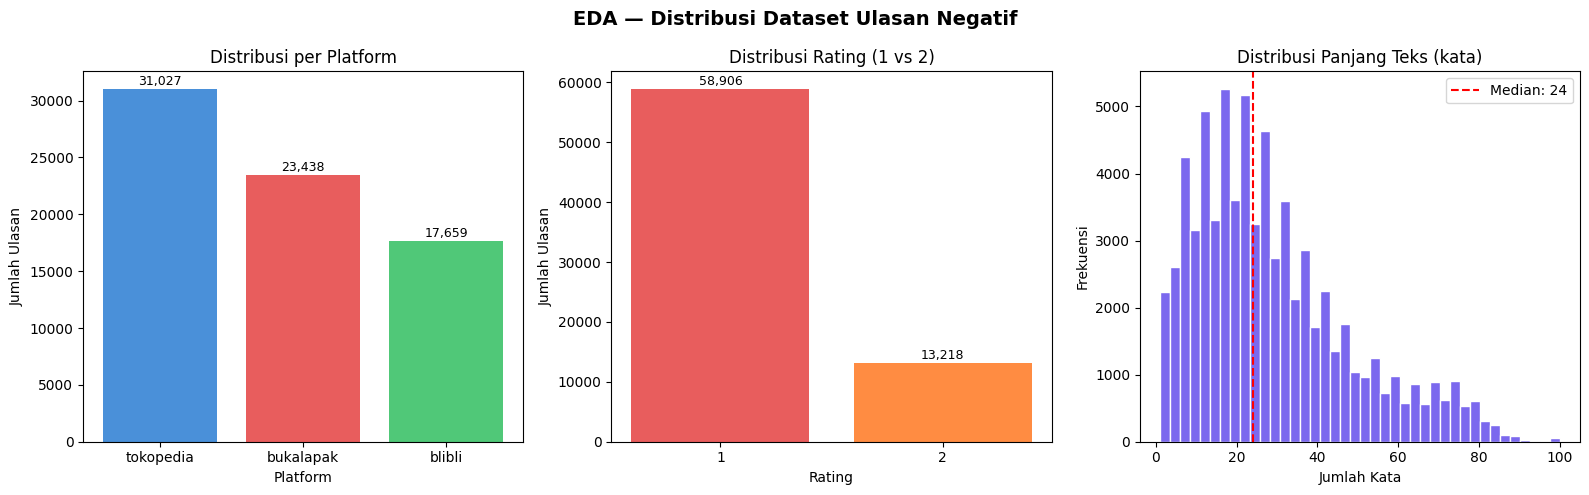


Statistik Panjang Teks (kata):
count    72124.00
mean        28.71
std         19.44
min          1.00
25%         14.00
50%         24.00
75%         39.00
max        193.00


In [8]:
# EDA 1 — Distribusi Platform & Rating
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('EDA — Distribusi Dataset Ulasan Negatif', fontsize=14, fontweight='bold')

# Distribusi platform
plat_counts = df_negative['platform'].value_counts()
colors_plat = ['#4A90D9', '#E85D5D', '#50C878']
bars = axes[0].bar(plat_counts.index, plat_counts.values, color=colors_plat)
axes[0].set_title('Distribusi per Platform')
axes[0].set_xlabel('Platform')
axes[0].set_ylabel('Jumlah Ulasan')
for bar, val in zip(bars, plat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Distribusi rating
rating_counts = df_negative['score'].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str), rating_counts.values,
            color=['#E85D5D', '#FF8C42'])
axes[1].set_title('Distribusi Rating (1 vs 2)')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Jumlah Ulasan')
for i, (idx, val) in enumerate(rating_counts.items()):
    axes[1].text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=9)

# Distribusi panjang teks
df_negative['text_len'] = df_negative['content_clean'].str.split().str.len()
axes[2].hist(df_negative['text_len'].clip(upper=100), bins=40, color='#7B68EE', edgecolor='white')
axes[2].set_title('Distribusi Panjang Teks (kata)')
axes[2].set_xlabel('Jumlah Kata')
axes[2].set_ylabel('Frekuensi')
axes[2].axvline(df_negative['text_len'].median(), color='red', linestyle='--',
                label=f'Median: {df_negative["text_len"].median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nStatistik Panjang Teks (kata):')
print(df_negative['text_len'].describe().round(2).to_string())

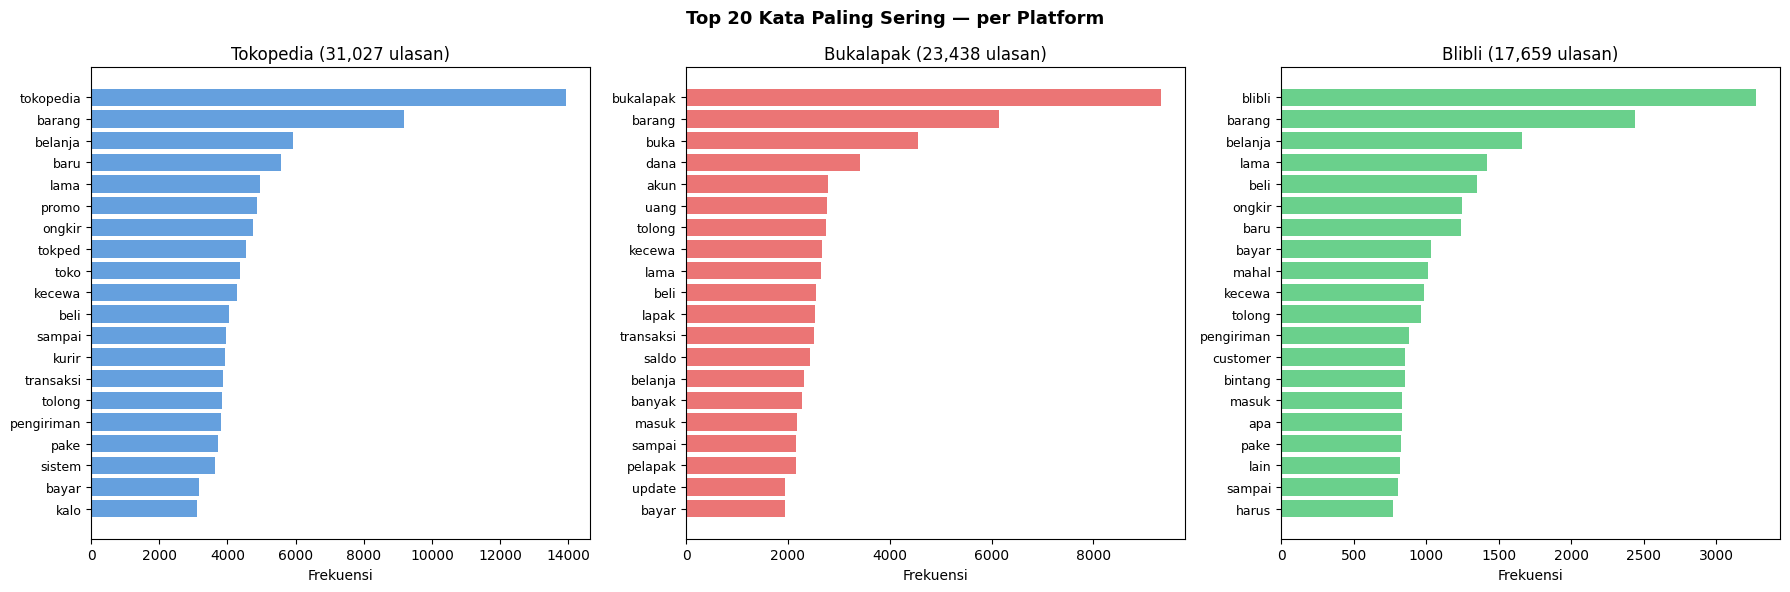

In [12]:
# EDA 2 — Kata Paling Sering Muncul per Platform
from collections import Counter

STOPWORDS_ID = {
    'yang','dan','di','ke','dari','dengan','untuk','ini','itu','tidak','ada',
    'saya','kamu','kami','kita','mereka','dia','ia','adalah','atau','juga',
    'bisa','sudah','akan','belum','pada','oleh','karena','tapi','tetapi',
    'jadi','kalau','lebih','sangat','sekali','punya','buat','sama','lagi',
    'setelah','sebelum','saat','ketika','sering','selalu','masih','terus',
    'mau','bisa','maka','agar','supaya','bahwa','seperti','hanya','malah',
    'lalu','kemudian','begitu','kok','sih','nih','deh','dong','loh','ya',
    'banget','aja','nih','tuh','emang', 'kali', 'gitu', 'gimana',
    'handphone', 'aplikasi', 'app', 'apk', 'nya', 'sekarang','dulu','hari',
    'padahal','kenapa'
}

def get_top_words(texts, n=20):
    words = []
    for t in texts:
        words.extend([w for w in str(t).split() if len(w) > 2 and w not in STOPWORDS_ID])
    return Counter(words).most_common(n)

platforms = df_negative['platform'].unique()
fig, axes = plt.subplots(1, len(platforms), figsize=(6*len(platforms), 6))
if len(platforms) == 1:
    axes = [axes]
fig.suptitle('Top 20 Kata Paling Sering — per Platform', fontsize=13, fontweight='bold')

plat_colors = {'tokopedia': '#4A90D9', 'bukalapak': '#E85D5D', 'blibli': '#50C878'}

for ax, plat in zip(axes, platforms):
    texts    = df_negative[df_negative['platform'] == plat]['content_clean']
    top_wds  = get_top_words(texts, 20)
    words_   = [w for w, c in top_wds]
    counts_  = [c for w, c in top_wds]
    color    = plat_colors.get(plat, '#888')
    ax.barh(words_[::-1], counts_[::-1], color=color, alpha=0.85)
    ax.set_title(f'{plat.title()} ({len(texts):,} ulasan)')
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/eda_topwords.png', dpi=150, bbox_inches='tight')
plt.show()

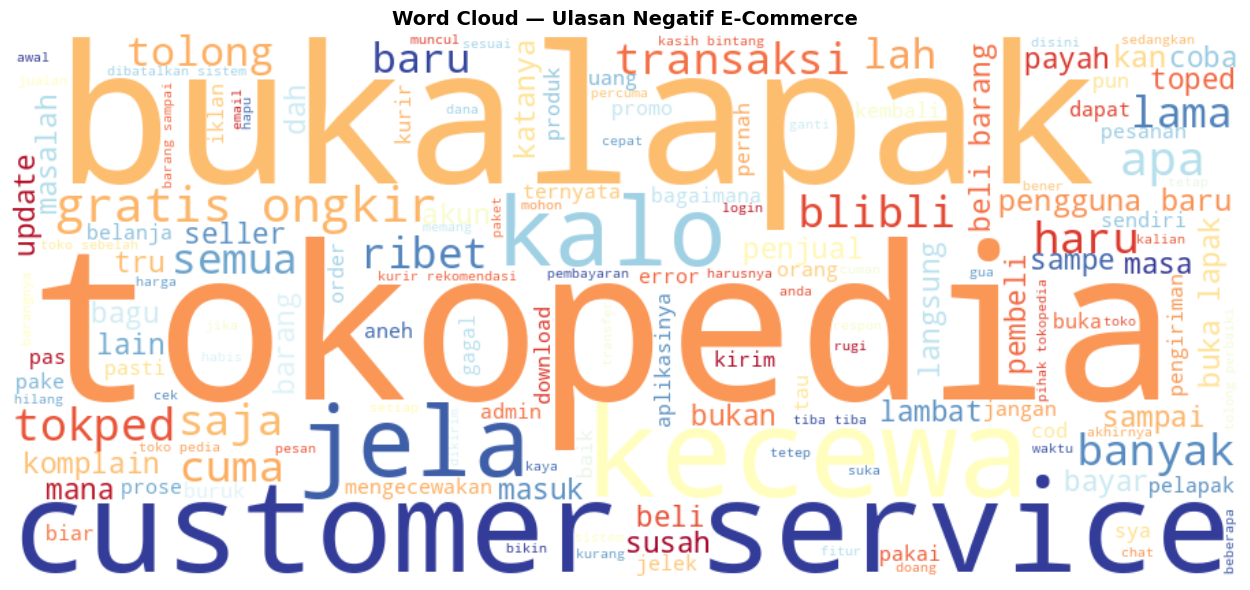

In [ ]:
# EDA 3 — Word Cloud gabungan
if HAS_WORDCLOUD:
    all_text = ' '.join(df_negative['content_clean'].dropna())
    words_filtered = ' '.join(
        w for w in all_text.split() if w not in STOPWORDS_ID and len(w) > 2
    )
    wc = WordCloud(
        width=900, height=400, background_color='white',
        colormap='RdYlBu_r', max_words=150
    ).generate(words_filtered)

    plt.figure(figsize=(15, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud — Ulasan Negatif E-Commerce', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_PATH}/eda_wordcloud.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('WordCloud tidak tersedia — lewati visualisasi ini.')

## 6. Labeling Aspek — Rule-Based

In [14]:
# Definisi Label
ASPECT_LABELS = {
    'Performa & Bug'         : 0,
    'Pembayaran & Transaksi' : 1,
    'UI/UX'                  : 2,
    'Layanan Pelanggan'      : 3,
    'Fitur Aplikasi'         : 4,
    'Pengiriman & Logistik'  : 5,   
    'Produk & Penjual'       : 6,   
    'Promosi & Voucher'      : 7,   
    'Lainnya'                : 8,   
}

ASPECT_NAMES   = {v: k for k, v in ASPECT_LABELS.items()}
NUM_ASPECTS    = len(ASPECT_LABELS)

print(f'Aspek    ({NUM_ASPECTS}): {list(ASPECT_LABELS.keys())}')

Aspek    (9): ['Performa & Bug', 'Pembayaran & Transaksi', 'UI/UX', 'Layanan Pelanggan', 'Fitur Aplikasi', 'Pengiriman & Logistik', 'Produk & Penjual', 'Promosi & Voucher', 'Lainnya']


In [15]:
# Keyword Dictionary per Aspek
ASPECT_KEYWORDS = {
    'Performa & Bug': [
        'lambat','lama','lag','loading','crash','force close','error',
        'bug','hang','macet','freeze','not responding','gagal buka',
        'tidak bisa dibuka','berat','lola','overheat','panas','boros baterai',
        'aplikasi mati','keluar sendiri','restart sendiri','server','down',
        'maintenance','gagal load','tidak mau buka','sulit dibuka',
        'tidak respon','black screen','blank','muter terus','buffering',
        'time out','timeout','koneksi','sinyal','internet','wifi','offline',
        'not found','update gagal','install gagal','uninstall','hapus aplikasi',
        'tidak stabil','sering mati','keluar tiba','force stop',
        'not open','cannot open','tidak terbuka',
    ],
    'Pembayaran & Transaksi': [
        'bayar','pembayaran','transaksi','transfer','refund','dana kembali',
        'saldo','duit','uang','voucher','promo','diskon','cashback','koin','poin',
        'gopay','ovo','dana','bca','mandiri','bni','bri','alfamart','indomaret',
        'checkout','order','pesanan','tagihan','cicilan','kredit','paylater',
        'virtual account','rekening','pengembalian','uang kembali',
        'tidak sampai','dana hilang','saldo hilang','double charge','kena biaya',
        'biaya tambahan','fee','potongan','dipotong','terdebet','tertagih',
        'gagal bayar','tidak bisa bayar','pending','tertahan','dibekukan',
        'limit','saldo tidak cukup','kurang saldo','kelebihan bayar',
        'tipu','penipuan','scam','menipu','tidak sesuai harga',
    ],
    'UI/UX': [
        'tampilan','desain','layout','interface','antarmuka','ui','ux',
        'membingungkan','bingung','susah','sulit','ribet','rumit',
        'tidak user friendly','tidak intuitif','menu','navigasi',
        'ikon','icon','font','huruf','warna','gelap','terang','dark mode',
        'tema','tidak nyaman','kurang nyaman','aneh','jelek tampilan',
        'tidak enak dilihat','tombol','button','scroll','klik',
        'tidak ketemu','hilang menu','pindah','berubah','update tampilan',
        'terlalu','tata letak','posisi','ukuran','kecil','besar',
        'tidak proporsional','tidak rapi','berantakan','kompleks',
        'susah ditemukan','tidak bisa ditemukan',
    ],
    'Layanan Pelanggan': [
        'cs','customer service','customer support','layanan pelanggan',
        'bantuan','help center','admin','operator','chat support',
        'kontak','hubungi','email','telpon','telepon','call center',
        'hotline','whatsapp','tidak dibalas','tidak respon','lambat balas',
        'lama balas','tidak ada respon','komplain','keluhan','laporan',
        'tidak ditangani','diabaikan','cuek','tidak membantu','tidak berguna',
        'tidak profesional','kasar','tidak ramah','bot','otomatis',
        'autorespond','template jawaban','solusi','penyelesaian',
        'tidak ada solusi','tidak diselesaikan','berputar','ping pong',
        'lempar tanggung jawab','tidak ada kejelasan','dibiarkan',
        'tidak ditindaklanjuti','slow respon','tidak fast respon',
    ],
    'Fitur Aplikasi': [
        'fitur','fungsi','feature','update','pembaruan','versi baru','upgrade',
        'notifikasi','notif','push notification','pembelian','ulasan','review',
        'pencarian','search','filter','sort','kategori','rekomendasi',
        'keranjang','wishlist','favorit','history','riwayat',
        'lacak','tracking','status','pelacakan','pengiriman',
        'foto','kamera','upload','gambar','video',
        'login','daftar','registrasi','password','akun',
        'verifikasi','otp','sms','konfirmasi','tidak berfungsi',
        'fitur hilang','tidak ada fitur','kurang fitur',
        'tidak update','perlu pembaruan',
    ],
    'Pengiriman & Logistik': [
        'kurir','ekspedisi','logistik','jne','jnt','j&t','sicepat','si cepat',
        'anteraja','id express','idexpress','id ekspres','shopee express',
        'gosend','grab express','lion parcel','pos indonesia','tiki','wahana',
        'ninja express','ninja xpress','rpx','sap express',
        'telat kirim','terlambat kirim','melebihi estimasi','melewati estimasi',
        'estimasi pengiriman','lama kirim','lama sampai','lambat sampai',
        'tidak dikirim','belum dikirim','tidak sampai','belum sampai',
        'nyasar','salah kirim','salah alamat','salah tujuan',
        'paket hilang','barang hilang','tidak ada kabar','tidak ada update',
        'diam di tempat','tidak bergerak','tidak ada pergerakan',
        'mengendap','ngendon','tertahan di gudang','tertahan di agen',
        'tidak pick up','tidak dijemput','tidak diambil',
        'retur','diretur','dikembalikan','gagal antar','gagal kirim',
        'tidak terkirim','cancel pengiriman','batal pengiriman',
        'paket rusak','barang rusak','kemasan rusak','kotak rusak',
        'lecet','penyok','basah','sobek','terbuka','tidak disegel',
        'resi','nomor resi','tidak ada resi','cek resi','lacak paket',
        'status pengiriman','tidak terupdate','tidak update resi',
        'ongkir','ongkos kirim','biaya kirim','gratis ongkir','bebas ongkir',
        'ongkir mahal','ongkir tinggi','subsidi ongkir',
    ],
    'Produk & Penjual': [
        'produk','barang','item','kualitas','kw','palsu','aspal','tidak asli',
        'tidak original','bukan original','tidak sesuai','tidak cocok',
        'berbeda','beda','tidak seperti','tidak sama','menipu',
        'foto berbeda','foto tidak sesuai','deskripsi tidak sesuai',
        'rusak','cacat','defect','tidak berfungsi','tidak menyala',
        'tidak lengkap','kurang','minus','tidak sempurna',
        'penjual','seller','toko','merchant','jualan',
        'penjual nakal','seller nakal','toko nakal','tidak amanah',
        'tidak jujur','bohong','tipu','curang','tidak bertanggung jawab',
        'tidak responsif','seller tidak respon','toko tidak respon',
        'tidak mau ganti','tidak mau retur','tidak mau refund',
        'tolak komplain','tidak mau terima komplain',
        'stok','stok habis','tidak tersedia','tidak ada stok','out of stock',
        'kosong','kehabisan','ready stock','pre order','po',
        'barang tidak ada','tidak tersedia','sudah habis',
        'harga tidak sesuai','harga berbeda','harga berubah',
        'lebih mahal','overpricing','tidak worth','tidak sebanding',
        'garansi','klaim garansi','tidak ada garansi','garansi tidak berlaku',
        'tidak mau klaim','penukaran','pengembalian barang',
    ],
    'Promosi & Voucher': [
        'voucher','kupon','kupon diskon','kode promo','kode voucher',
        'tidak bisa dipakai','tidak bisa digunakan','tidak berlaku',
        'gagal pakai','gagal gunakan','tidak valid','expired','kadaluarsa',
        'sudah diklaim','tidak bisa diklaim','klaim gagal',
        'voucher hilang','kupon hilang','promo hilang',
        'gratis ongkir','bebas ongkir','ongkir gratis','subsidi ongkir',
        'cashback','tidak dapat cashback','cashback tidak masuk',
        'poin tidak masuk','koin tidak masuk','reward tidak masuk',
        'flash sale','daily deals','harbolnas','promo','promosi',
        'tidak kebagian','kehabisan','promo habis','promo bohong',
        'promo palsu','promo tidak sesuai','iklan bohong','iklan menipu',
        'syarat promo','ketentuan promo','tidak memenuhi syarat',
        'minimum belanja','minimum order','minimal pembelian',
        'tidak mencapai minimum','tidak memenuhi minimum',
        'dibatalkan sistem','batal sistem','cancel sistem','sistem membatalkan',
        'pesanan dibatalkan','order dibatalkan','otomatis dibatalkan',
        'iklan','iklan mengganggu','iklan terus','iklan mulu',
        'banyak iklan','terlalu banyak iklan','spam iklan','ads',
    ],
}

print('Keyword dictionary siap')

Keyword dictionary siap


In [16]:
# Fungsi Annotasi Rule-Based
def rule_based_annotate(text, score=None):
    text_lower = str(text).lower()

    # Tentukan Aspek berdasarkan keyword
    aspek_scores = {asp: 0 for asp in ASPECT_KEYWORDS}
    for asp, keywords in ASPECT_KEYWORDS.items():
        for kw in keywords:
            if kw in text_lower:
                aspek_scores[asp] += 1

    best_aspek  = max(aspek_scores, key=aspek_scores.get)
    best_score  = aspek_scores[best_aspek]
    aspek_label = best_aspek if best_score > 0 else 'Lainnya'

    # Sentimen dari rating
    if score is not None:
        sentimen = 'negatif' if int(score) <= 2 else 'positif'
    else:
        sentimen = 'negatif'

    return {'aspek': aspek_label, 'sentimen': sentimen}


# Sampling & Annotasi
if ANNOTATION_SAMPLE and ANNOTATION_SAMPLE < len(df_negative):
    n_per_platform = ANNOTATION_SAMPLE // df_negative['platform'].nunique()
    parts = []
    for plat, grp in df_negative.groupby('platform'):
        sampled = grp.sample(min(len(grp), n_per_platform), random_state=SEED)
        parts.append(sampled)
    df_to_annotate = pd.concat(parts).reset_index(drop=True)

    if len(df_to_annotate) < ANNOTATION_SAMPLE:
        used_idx  = set(df_to_annotate.index)
        remaining = df_negative[~df_negative.index.isin(used_idx)]
        extra     = remaining.sample(
            min(ANNOTATION_SAMPLE - len(df_to_annotate), len(remaining)),
            random_state=SEED
        )
        df_to_annotate = pd.concat([df_to_annotate, extra]).reset_index(drop=True)
else:
    df_to_annotate = df_negative.copy()

print(f'Data yang akan dianotasi: {len(df_to_annotate):,} ulasan')
print(df_to_annotate['platform'].value_counts().to_string())

# Jalankan rule-based annotation
print('\nMenjalankan rule-based annotation...')
annotations = [
    rule_based_annotate(text, score)
    for text, score in tqdm(
        zip(df_to_annotate['content_clean'], df_to_annotate['score']),
        desc='Annotasi', total=len(df_to_annotate)
    )
]

df_annotated                = df_to_annotate.copy()
df_annotated['aspek']       = [a['aspek']    for a in annotations]
df_annotated['sentimen']    = [a['sentimen'] for a in annotations]
df_annotated['aspek_id']    = df_annotated['aspek'].map(ASPECT_LABELS)

ANNOTATION_SAVE_PATH = f'{OUTPUT_PATH}/annotated_reviews.csv'
df_annotated.to_csv(ANNOTATION_SAVE_PATH, index=False)

print(f'\nAnnotasi selesai: {len(df_annotated):,} ulasan')
print('\nDistribusi Aspek:')
print(df_annotated['aspek'].value_counts().to_string())
print('\nDistribusi Sentimen:')
print(df_annotated['sentimen'].value_counts().to_string())

n_lainnya   = (df_annotated['aspek'] == 'Lainnya').sum()
pct_lainnya = n_lainnya / len(df_annotated) * 100
print(f'\nCatatan: "Lainnya" = {n_lainnya} ({pct_lainnya:.1f}%) — tidak ter-cover keyword')

Data yang akan dianotasi: 72,124 ulasan
platform
tokopedia    31027
bukalapak    23438
blibli       17659

Menjalankan rule-based annotation...


Annotasi:   0%|          | 0/72124 [00:00<?, ?it/s]


Annotasi selesai: 72,124 ulasan

Distribusi Aspek:
aspek
Pembayaran & Transaksi    21306
Performa & Bug            15256
Produk & Penjual          10189
Fitur Aplikasi             6214
Lainnya                    5609
UI/UX                      4649
Pengiriman & Logistik      3978
Layanan Pelanggan          3399
Promosi & Voucher          1524

Distribusi Sentimen:
sentimen
negatif    72124

Catatan: "Lainnya" = 5609 (7.8%) — tidak ter-cover keyword


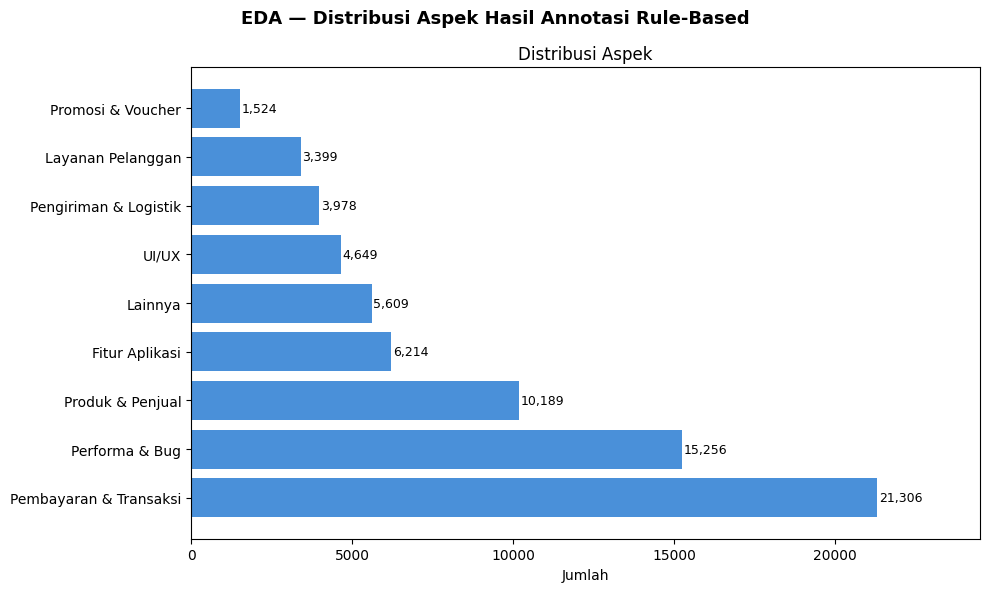

EDA label tersimpan


In [17]:
# EDA 4 — Distribusi Label Hasil Annotasi
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.suptitle('EDA — Distribusi Aspek Hasil Annotasi Rule-Based', fontsize=13, fontweight='bold')

aspek_cnt = df_annotated['aspek'].value_counts()
bars = ax.barh(aspek_cnt.index, aspek_cnt.values, color='#4A90D9')
ax.set_title('Distribusi Aspek')
ax.set_xlabel('Jumlah')
ax.tick_params(axis='y', labelsize=10)

for i, v in enumerate(aspek_cnt.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)

ax.set_xlim(0, aspek_cnt.values.max() * 1.15)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/eda_label_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA label tersimpan')

## 7. Tokenisasi & Split Dataset

In [ ]:
# Tokenisasi
def simple_tokenize(text):
    return str(text).lower().split()

df_annotated['tokens'] = df_annotated['content_clean'].apply(simple_tokenize)
df_annotated['token_count'] = df_annotated['tokens'].str.len()

print('Statistik token per ulasan:')
print(df_annotated['token_count'].describe().round(2).to_string())
print(f'\nContoh tokenisasi:')
for i in range(3):
    print(f'  [{i+1}] {df_annotated["tokens"].iloc[i][:15]}...')

Statistik token per ulasan:
count    72124.00
mean        28.71
std         19.44
min          1.00
25%         14.00
50%         24.00
75%         39.00
max        193.00

Contoh tokenisasi:
  [1] ['kecewa', 'sekali', 'baru', 'pertama', 'kali', 'daftar', 'dan', 'niatnya', 'mau', 'chekout', 'first', 'time', 'krna', 'dpet', 'promo']...
  [2] ['berkali', 'kali', 'pengiriman', 'bermasalah', 'paket', 'sering', 'tidak', 'sampai', 'padahal', 'sudah', 'berminggu', 'minggu', 'dikomplain', 'juga', 'lambat']...
  [3] ['menu', 'kupon', 'sering', 'hilang', 'dan', 'sangat', 'sangat', 'sulit', 'dicari', 'dilayout', 'tidak', 'ada', 'dimenu', 'profil', 'juga']...


In [16]:
# Split 80 / 10 / 10 — stratified berdasarkan aspek
df_train_val, df_test = train_test_split(
    df_annotated, test_size=0.10,
    random_state=SEED, stratify=df_annotated['aspek_id']
)
df_train, df_val = train_test_split(
    df_train_val, test_size=0.1111,   # ~10% dari total
    random_state=SEED, stratify=df_train_val['aspek_id']
)

df_train.to_csv(f'{OUTPUT_PATH}/train.csv', index=False)
df_val.to_csv(f'{OUTPUT_PATH}/val.csv',     index=False)
df_test.to_csv(f'{OUTPUT_PATH}/test.csv',   index=False)

total = len(df_annotated)
print('Split Dataset (80/10/10):')
print(f'  Train : {len(df_train):,} ({len(df_train)/total*100:.1f}%)')
print(f'  Val   : {len(df_val):,} ({len(df_val)/total*100:.1f}%)')
print(f'  Test  : {len(df_test):,} ({len(df_test)/total*100:.1f}%)')

print('\nDistribusi Aspek — Train:')
print(df_train['aspek'].value_counts().to_string())

Split Dataset (80/10/10):
  Train : 57,699 (80.0%)
  Val   : 7,212 (10.0%)
  Test  : 7,213 (10.0%)

Distribusi Aspek — Train:
aspek
Pembayaran & Transaksi    17045
Performa & Bug            12204
Produk & Penjual           8151
Fitur Aplikasi             4972
Lainnya                    4487
UI/UX                      3719
Pengiriman & Logistik      3182
Layanan Pelanggan          2719
Promosi & Voucher          1220


## 8. Baseline — TF-IDF + Logistic Regression

In [17]:
print('=' * 60)
print('BASELINE: TF-IDF + Logistic Regression')
print('=' * 60)

tfidf   = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=2)
X_train = tfidf.fit_transform(df_train['content_clean'])
X_val   = tfidf.transform(df_val['content_clean'])
X_test  = tfidf.transform(df_test['content_clean'])

# Klasifikasi Aspek
lr_aspek = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED, n_jobs=-1)
lr_aspek.fit(X_train, df_train['aspek_id'])

# Evaluasi pada test set
t0             = time.time()
bl_aspek_preds = lr_aspek.predict(X_test)
bl_infer_time  = (time.time() - t0) / len(df_test) * 1000

# Metrik
bl_aspek_f1  = f1_score(df_test['aspek_id'],     bl_aspek_preds, average='macro', zero_division=0)
bl_aspek_p   = precision_score(df_test['aspek_id'], bl_aspek_preds, average='macro', zero_division=0)
bl_aspek_r   = recall_score(df_test['aspek_id'],    bl_aspek_preds, average='macro', zero_division=0)
bl_aspek_acc = accuracy_score(df_test['aspek_id'],  bl_aspek_preds)

baseline_results = {
    'label'           : 'TF-IDF + LR (Baseline)',
    'f1'              : bl_aspek_f1,
    'precision'       : bl_aspek_p,
    'recall'          : bl_aspek_r,
    'accuracy'        : bl_aspek_acc,
    'training_time_min': 0,
    'inference_ms'    : bl_infer_time,
    'preds'           : bl_aspek_preds.tolist(),
    'labels'          : df_test['aspek_id'].tolist(),
}

print(f'F1       : {bl_aspek_f1:.4f}')
print(f'Precision: {bl_aspek_p:.4f}')
print(f'Recall   : {bl_aspek_r:.4f}')
print(f'Accuracy : {bl_aspek_acc:.4f}')
print(f'Inference: {bl_infer_time:.2f} ms/sampel')

print('\nClassification Report — Aspek:')
print(classification_report(
    df_test['aspek_id'], bl_aspek_preds,
    target_names=list(ASPECT_LABELS.keys()), zero_division=0
))

# Simpan model baseline
BL_TFIDF_PATH    = f'{OUTPUT_PATH}/baseline_tfidf.joblib'
BL_LR_ASPEK_PATH = f'{OUTPUT_PATH}/baseline_lr_aspek.joblib'
joblib.dump(tfidf,    BL_TFIDF_PATH)
joblib.dump(lr_aspek, BL_LR_ASPEK_PATH)

print(f'\nModel baseline disimpan:')
print(f'  TF-IDF   : {BL_TFIDF_PATH}')
print(f'  LR Aspek : {BL_LR_ASPEK_PATH}')

BASELINE: TF-IDF + Logistic Regression
F1       : 0.7451
Precision: 0.7820
Recall   : 0.7229
Accuracy : 0.7984
Inference: 0.00 ms/sampel

Classification Report — Aspek:
                        precision    recall  f1-score   support

        Performa & Bug       0.82      0.84      0.83      1526
Pembayaran & Transaksi       0.83      0.90      0.86      2131
                 UI/UX       0.79      0.59      0.68       465
     Layanan Pelanggan       0.81      0.67      0.73       340
        Fitur Aplikasi       0.77      0.70      0.73       621
 Pengiriman & Logistik       0.76      0.74      0.75       398
      Produk & Penjual       0.73      0.75      0.74      1019
     Promosi & Voucher       0.73      0.43      0.54       152
               Lainnya       0.79      0.89      0.84       561

              accuracy                           0.80      7213
             macro avg       0.78      0.72      0.75      7213
          weighted avg       0.80      0.80      0.79      72

## 9. Fine-Tuning IndoBERT 

In [18]:
# Dataset PyTorch
class ABSADataset(Dataset):
    def __init__(self, texts, aspek_labels, tokenizer, max_len):
        self.texts        = texts
        self.aspek_labels = aspek_labels
        self.tokenizer    = tokenizer
        self.max_len      = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'aspek_label'   : torch.tensor(self.aspek_labels[idx], dtype=torch.long),
        }


# Model ABSA 
class ABSAModel(nn.Module):
    def __init__(self, model_name, num_aspects, dropout=0.3): 
        super().__init__()
        self.encoder = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=2, ignore_mismatched_sizes=True
        )
        hidden_size     = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.aspek_head = nn.Linear(hidden_size, num_aspects)

    def forward(self, input_ids, attention_mask):
        out    = self.encoder.base_model(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.dropout(out.last_hidden_state[:, 0, :])
        return self.aspek_head(pooled) 


# DataLoader helper
def create_dataloaders(df_tr, df_v, df_te, tokenizer, batch_size):
    def make(df):
        return ABSADataset(
            df['content_clean'].tolist(),
            df['aspek_id'].tolist(),
            tokenizer, MAX_SEQ_LENGTH
        )
    num_workers = 2 if os.cpu_count() and os.cpu_count() > 2 else 0
    return (
        DataLoader(make(df_tr), batch_size=batch_size, shuffle=True,
                   num_workers=num_workers, pin_memory=torch.cuda.is_available()),
        DataLoader(make(df_v),  batch_size=batch_size, shuffle=False,
                   num_workers=num_workers, pin_memory=torch.cuda.is_available()),
        DataLoader(make(df_te), batch_size=batch_size, shuffle=False,
                   num_workers=num_workers, pin_memory=torch.cuda.is_available())
    )


# Train satu epoch
def train_epoch(model, loader, optimizer, scheduler):
    model.train()
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    total_loss = 0.0
    for batch in tqdm(loader, desc='  Training', leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        aspek_lbl      = batch['aspek_label'].to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, aspek_lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


# Evaluasi
def evaluate(model, loader):
    model.eval()
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
    a_preds, a_labels = [], []
    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(loader, desc='  Evaluasi', leave=False):
            input_ids      = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            aspek_lbl      = batch['aspek_label'].to(DEVICE)

            logits      = model(input_ids, attention_mask)
            total_loss += criterion(logits, aspek_lbl).item()
            a_preds.extend(logits.argmax(1).cpu().numpy())
            a_labels.extend(aspek_lbl.cpu().numpy())

    return {
        'loss'     : total_loss / len(loader),
        'f1'       : f1_score(a_labels,  a_preds, average='macro', zero_division=0),
        'precision': precision_score(a_labels, a_preds, average='macro', zero_division=0),
        'recall'   : recall_score(a_labels,   a_preds, average='macro', zero_division=0),
        'accuracy' : accuracy_score(a_labels, a_preds),
        'preds'    : a_preds,
        'labels'   : a_labels,
    }


# Fungsi Training Penuh
def train_model(model_name, batch_size, label):
    print(f'\n{"="*65}')
    print(f'TRAINING: {label}')
    print(f'{"="*65}')

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_loader, val_loader, test_loader = create_dataloaders(
        df_train, df_val, df_test, tokenizer, batch_size
    )

    model     = ABSAModel(model_name, NUM_ASPECTS).to(DEVICE)  # hapus NUM_SENTIMENTS
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    history     = {'train_loss': [], 'val_loss': [], 'val_f1': []}  # key konsisten
    best_val_f1 = 0.0
    best_path   = f'{OUTPUT_PATH}/best_{label.replace(" ", "_").lower()}.pt'
    t_start     = time.time()

    for epoch in range(1, EPOCHS + 1):
        print(f'\n  Epoch {epoch}/{EPOCHS}')
        train_loss  = train_epoch(model, train_loader, optimizer, scheduler)
        val_metrics = evaluate(model, val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_f1'].append(val_metrics['f1'])  # key konsisten

        print(f'  Train Loss : {train_loss:.4f}')
        print(f'  Val Loss   : {val_metrics["loss"]:.4f}')
        print(f'  Val F1     : {val_metrics["f1"]:.4f}  Acc: {val_metrics["accuracy"]:.4f}')

        if val_metrics['f1'] > best_val_f1:  
            best_val_f1 = val_metrics['f1']
            torch.save(model.state_dict(), best_path)
            print(f'  ✓ Best model disimpan (F1: {best_val_f1:.4f})')

    training_time = time.time() - t_start

    # Muat bobot terbaik lalu evaluasi test set
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    print('\n  Evaluasi Test Set...')
    t_infer      = time.time()
    test_metrics = evaluate(model, test_loader)
    infer_time   = (time.time() - t_infer) / len(df_test) * 1000

    print(f'\n  ====== Hasil Test [{label}] ======')
    print(f'  F1        : {test_metrics["f1"]:.4f}')
    print(f'  Precision : {test_metrics["precision"]:.4f}')
    print(f'  Recall    : {test_metrics["recall"]:.4f}')
    print(f'  Accuracy  : {test_metrics["accuracy"]:.4f}')
    print(f'  Training Time  : {training_time/60:.1f} menit')
    print(f'  Inference Time : {infer_time:.2f} ms/sampel')

    return model, tokenizer, history, test_metrics, training_time, infer_time, best_path


print('Semua class dan fungsi training siap.')

Semua class dan fungsi training siap.


## 10. Fine-Tuning IndoBERT-Base

In [19]:
MODEL_BASE = 'indobenchmark/indobert-base-p1'

(
    model_base, tokenizer_base, history_base,
    test_metrics_base, train_time_base, infer_time_base, path_base
) = train_model(MODEL_BASE, BATCH_SIZE_BASE, 'IndoBERT Base FineTuned')


TRAINING: IndoBERT Base FineTuned


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

  Training:   0%|          | 0/3607 [00:00<?, ?it/s]

  Evaluasi:   0%|          | 0/451 [00:00<?, ?it/s]

  Train Loss : 0.6147
  Val Loss   : 0.6824
  Val F1     : 0.9042  Acc: 0.9267
  ✓ Best model disimpan (F1: 0.9042)

  Evaluasi Test Set...


  Evaluasi:   0%|          | 0/451 [00:00<?, ?it/s]


  ====== Hasil Test [IndoBERT Base FineTuned] ======
  F1        : 0.9043
  Precision : 0.9093
  Recall    : 0.9009
  Accuracy  : 0.9300
  Training Time  : 69.9 menit
  Inference Time : 8.22 ms/sampel


In [20]:
print('\nClassification Report — IndoBERT-Base (Aspek):')
print(classification_report(
    test_metrics_base['labels'], test_metrics_base['preds'],
    target_names=list(ASPECT_LABELS.keys()), zero_division=0
))


Classification Report — IndoBERT-Base (Aspek):
                        precision    recall  f1-score   support

        Performa & Bug       0.95      0.95      0.95      1526
Pembayaran & Transaksi       0.95      0.96      0.96      2131
                 UI/UX       0.92      0.84      0.88       465
     Layanan Pelanggan       0.86      0.92      0.89       340
        Fitur Aplikasi       0.91      0.95      0.93       621
 Pengiriman & Logistik       0.89      0.89      0.89       398
      Produk & Penjual       0.91      0.89      0.90      1019
     Promosi & Voucher       0.84      0.73      0.78       152
               Lainnya       0.95      0.98      0.96       561

              accuracy                           0.93      7213
             macro avg       0.91      0.90      0.90      7213
          weighted avg       0.93      0.93      0.93      7213



## 11. Fine-Tuning IndoBERT-Large

In [21]:
MODEL_LARGE = 'indobenchmark/indobert-large-p1'

(
    model_large, tokenizer_large, history_large,
    test_metrics_large, train_time_large, infer_time_large, path_large
) = train_model(MODEL_LARGE, BATCH_SIZE_LARGE, 'IndoBERT Large FineTuned')


TRAINING: IndoBERT Large FineTuned


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:50<?, ?B/s]

...

  Training:   0%|          | 0/7213 [00:00<?, ?it/s]

  Evaluasi:   0%|          | 0/902 [00:00<?, ?it/s]

  Train Loss : 0.5950
  Val Loss   : 0.6417
  Val F1     : 0.9364  Acc: 0.9526
  ✓ Best model disimpan (F1: 0.9364)

  Evaluasi Test Set...


  Evaluasi:   0%|          | 0/902 [00:00<?, ?it/s]


  ====== Hasil Test [IndoBERT Large FineTuned] ======
  F1        : 0.9275
  Precision : 0.9314
  Recall    : 0.9244
  Accuracy  : 0.9465
  Training Time  : 259.7 menit
  Inference Time : 28.09 ms/sampel


In [22]:
print('\nClassification Report — IndoBERT-Large (Aspek):')
print(classification_report(
    test_metrics_large['labels'], test_metrics_large['preds'],
    target_names=list(ASPECT_LABELS.keys()), zero_division=0
))


Classification Report — IndoBERT-Large (Aspek):
                        precision    recall  f1-score   support

        Performa & Bug       0.96      0.97      0.96      1526
Pembayaran & Transaksi       0.97      0.97      0.97      2131
                 UI/UX       0.93      0.86      0.89       465
     Layanan Pelanggan       0.91      0.94      0.92       340
        Fitur Aplikasi       0.94      0.96      0.95       621
 Pengiriman & Logistik       0.92      0.91      0.92       398
      Produk & Penjual       0.93      0.91      0.92      1019
     Promosi & Voucher       0.88      0.82      0.85       152
               Lainnya       0.95      0.98      0.97       561

              accuracy                           0.95      7213
             macro avg       0.93      0.92      0.93      7213
          weighted avg       0.95      0.95      0.95      7213



## 12. Evaluasi & Perbandingan Model

In [23]:
# Cek apakah Model Large berhasil ditraining
try:
    _ = test_metrics_large
    large_done = True
except NameError:
    large_done = False
    print('IndoBERT-Large belum selesai training — hanya menampilkan Baseline & Base')

all_results = []

# Baseline
all_results.append({
    'label'             : 'TF-IDF + LR (Baseline)',
    'f1'                : baseline_results['f1'],
    'precision'         : baseline_results['precision'],
    'recall'            : baseline_results['recall'],
    'accuracy'          : baseline_results['accuracy'],
    'training_time_min' : 0,
    'inference_ms'      : baseline_results['inference_ms'],
    'preds'             : baseline_results['preds'],
    'labels'            : baseline_results['labels'],
})

# IndoBERT-Base
all_results.append({
    'label'             : 'IndoBERT-Base (Fine-tuned)',
    'f1'                : test_metrics_base['f1'],
    'precision'         : test_metrics_base['precision'],
    'recall'            : test_metrics_base['recall'],
    'accuracy'          : test_metrics_base['accuracy'],
    'training_time_min' : train_time_base / 60,
    'inference_ms'      : infer_time_base,
    'preds'             : test_metrics_base['preds'],
    'labels'            : test_metrics_base['labels'],
})

# IndoBERT-Large
if large_done:
    all_results.append({
        'label'             : 'IndoBERT-Large (Fine-tuned)',
        'f1'                : test_metrics_large['f1'],
        'precision'         : test_metrics_large['precision'],
        'recall'            : test_metrics_large['recall'],
        'accuracy'          : test_metrics_large['accuracy'],
        'training_time_min' : train_time_large / 60,
        'inference_ms'      : infer_time_large,
        'preds'             : test_metrics_large['preds'],
        'labels'            : test_metrics_large['labels'],
    })

df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values('f1', ascending=False).reset_index(drop=True)

# Cetak tabel
print('\n' + '='*75)
print('TABEL PERBANDINGAN MODEL — KLASIFIKASI ASPEK')
print('='*75)
header = f'{"Model":<30} {"F1":>7} {"Precision":>10} {"Recall":>7} {"Accuracy":>9} {"Train(m)":>9} {"Infer(ms)":>10}'
print(header)
print('-'*75)
for _, r in df_results.iterrows():
    row = (f'{r["label"]:<30} '
           f'{r["f1"]:>7.4f} {r["precision"]:>10.4f} {r["recall"]:>7.4f} '
           f'{r["accuracy"]:>9.4f} {r["training_time_min"]:>9.1f} {r["inference_ms"]:>10.2f}')
    print(row)
print('='*75)
print(f'\n🏆 Model Terbaik : {df_results.iloc[0]["label"]}')
print(f'   F1 (Macro)   : {df_results.iloc[0]["f1"]:.4f}')
print(f'   Accuracy     : {df_results.iloc[0]["accuracy"]:.4f}')

# Simpan tabel
save_cols = [c for c in df_results.columns if c not in ['preds', 'labels']]
df_results[save_cols].to_csv(f'{OUTPUT_PATH}/model_comparison.csv', index=False)
print(f'\nTabel disimpan: {OUTPUT_PATH}/model_comparison.csv')


TABEL PERBANDINGAN MODEL — KLASIFIKASI ASPEK
Model                               F1  Precision  Recall  Accuracy  Train(m)  Infer(ms)
---------------------------------------------------------------------------
IndoBERT-Large (Fine-tuned)     0.9275     0.9314  0.9244    0.9465     259.7      28.09
IndoBERT-Base (Fine-tuned)      0.9043     0.9093  0.9009    0.9300      69.9       8.22
TF-IDF + LR (Baseline)          0.7451     0.7820  0.7229    0.7984       0.0       0.00

🏆 Model Terbaik : IndoBERT-Large (Fine-tuned)
   F1 (Macro)   : 0.9275
   Accuracy     : 0.9465

Tabel disimpan: /kaggle/working/model_comparison.csv


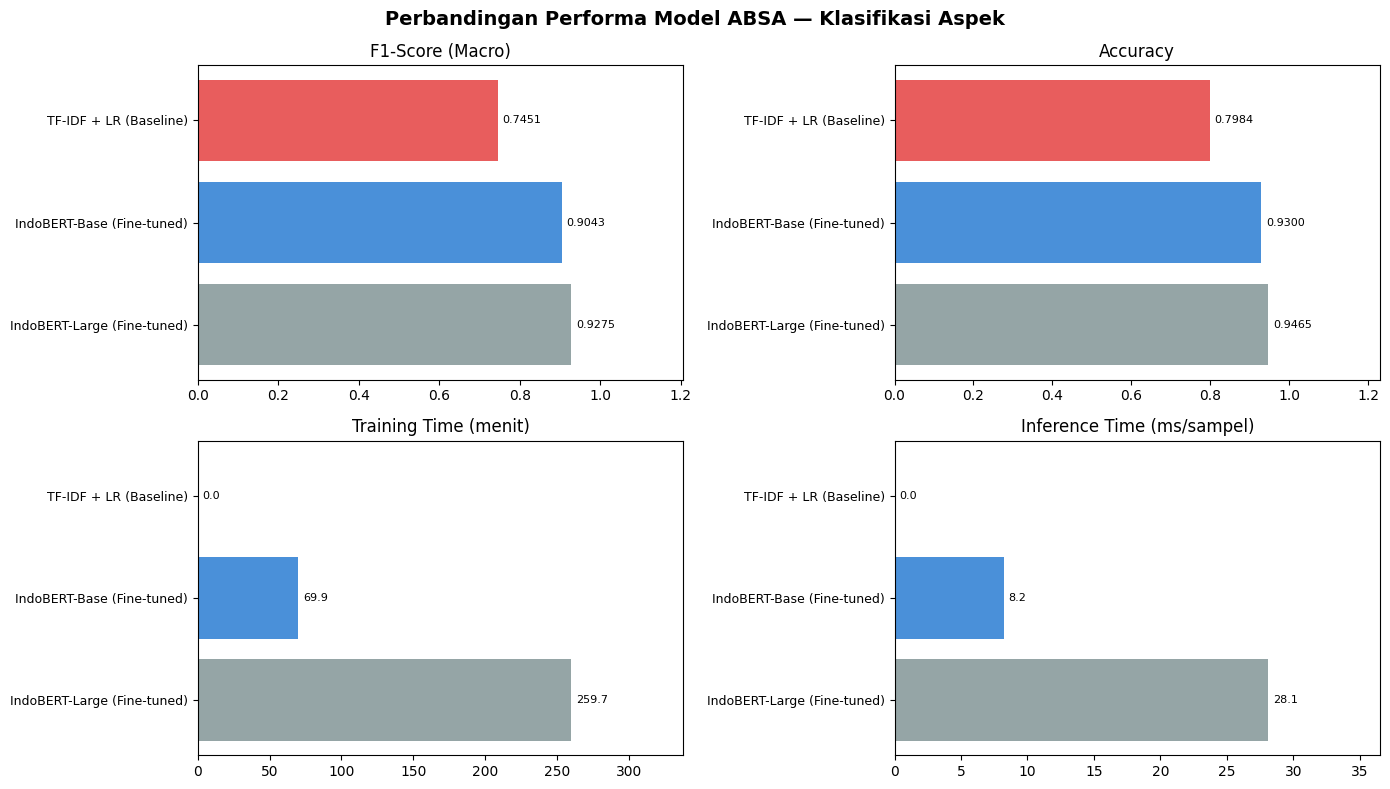

Visualisasi perbandingan disimpan


In [ ]:
# Visualisasi Perbandingan Metrik
model_labels = df_results['label'].tolist()
bar_colors   = ['#95A5A6', '#4A90D9', '#E85D5D'][:len(model_labels)]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))  
fig.suptitle('Perbandingan Performa Model ABSA — Klasifikasi Aspek',
             fontsize=14, fontweight='bold')

metrics_to_plot = [
    ('f1',                'F1-Score (Macro)'),
    ('accuracy',          'Accuracy'),
    ('training_time_min', 'Training Time (menit)'),
    ('inference_ms',      'Inference Time (ms/sampel)'),
]

for ax, (col, title) in zip(axes.flatten(), metrics_to_plot):
    vals = df_results[col].tolist()
    ax.barh(range(len(model_labels)), vals, color=bar_colors)
    ax.set_yticks(range(len(model_labels)))
    ax.set_yticklabels(model_labels, fontsize=9)
    ax.set_title(title)
    xlim = max(vals) * 1.3 if max(vals) > 0 else 1
    ax.set_xlim(0, xlim)
    fmt = '.1f' if 'menit' in title or 'ms' in title else '.4f'
    for i, v in enumerate(vals):
        ax.text(v + xlim * 0.01, i, f'{v:{fmt}}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi perbandingan disimpan')

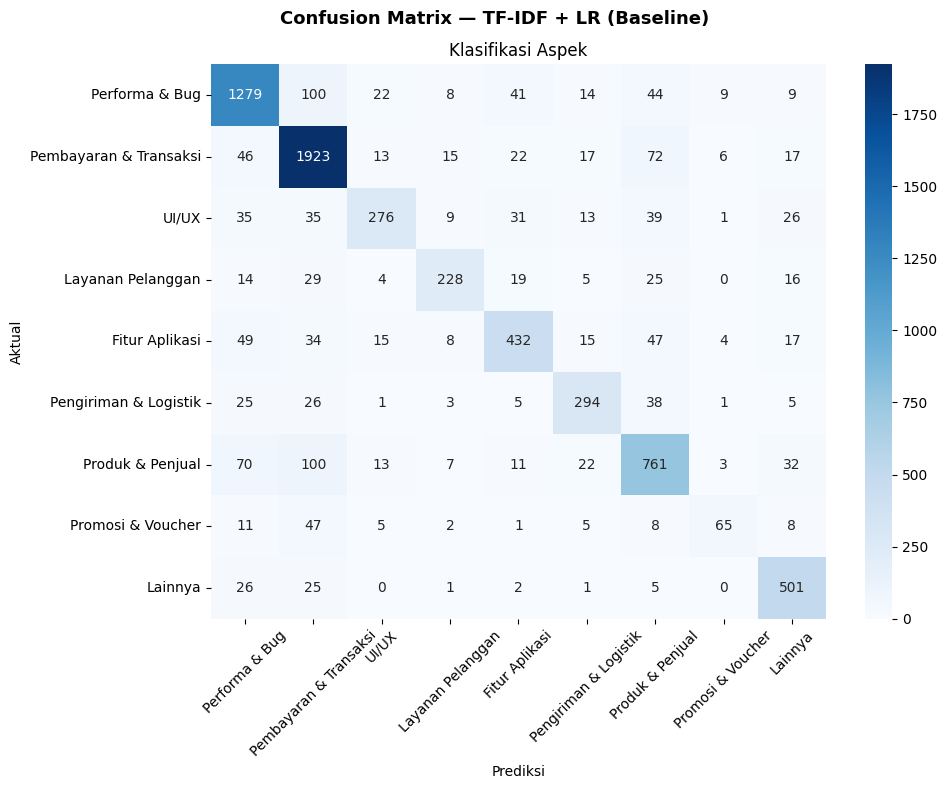

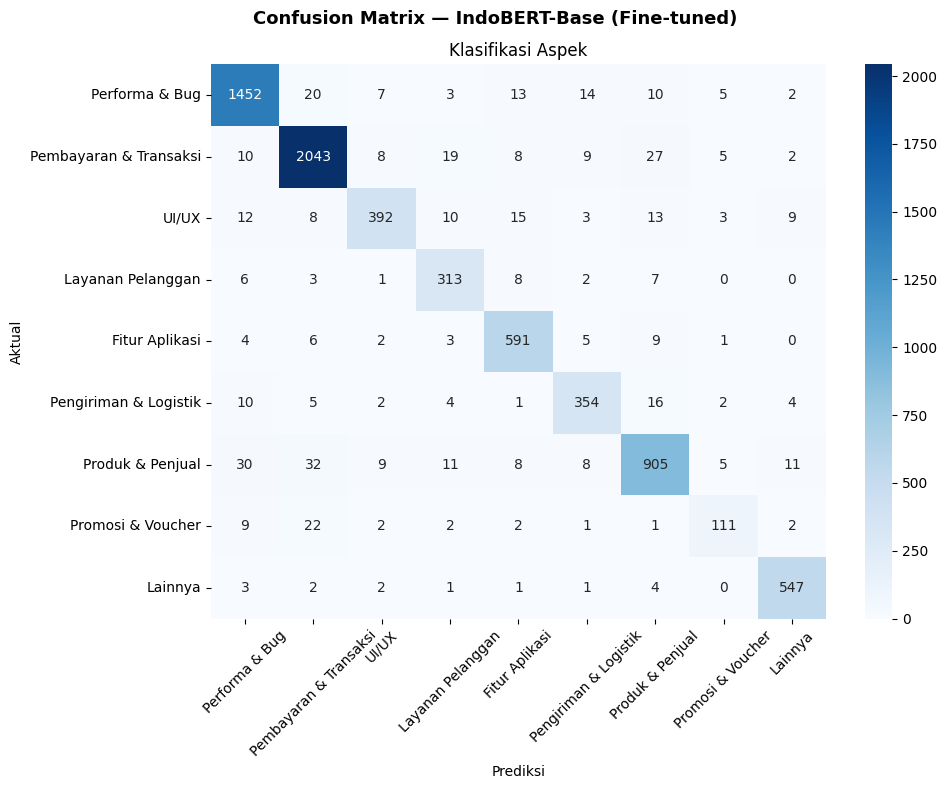

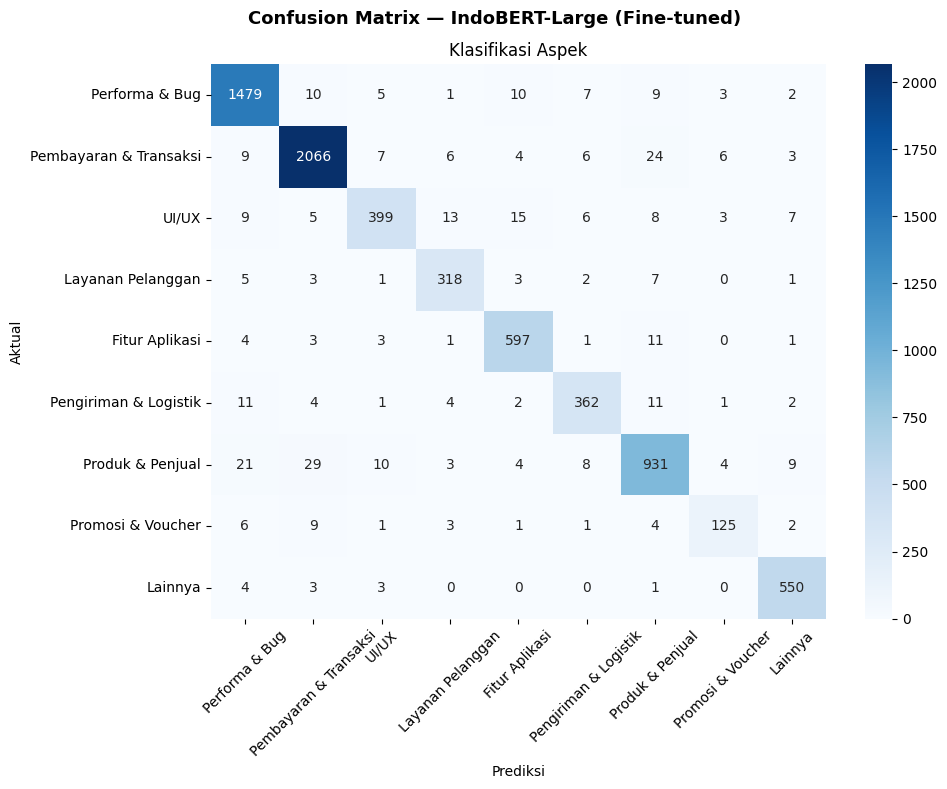

In [25]:
# Confusion Matrix
for row in all_results:
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))  
    fig.suptitle(f'Confusion Matrix — {row["label"]}', fontsize=13, fontweight='bold')

    sns.heatmap(
        confusion_matrix(row['labels'], row['preds']),
        annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=list(ASPECT_LABELS.keys()),
        yticklabels=list(ASPECT_LABELS.keys())
    )
    ax.set_title('Klasifikasi Aspek')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    fname = row['label'].replace(' ', '_').replace('/', '-').lower()
    plt.savefig(f'{OUTPUT_PATH}/confmat_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

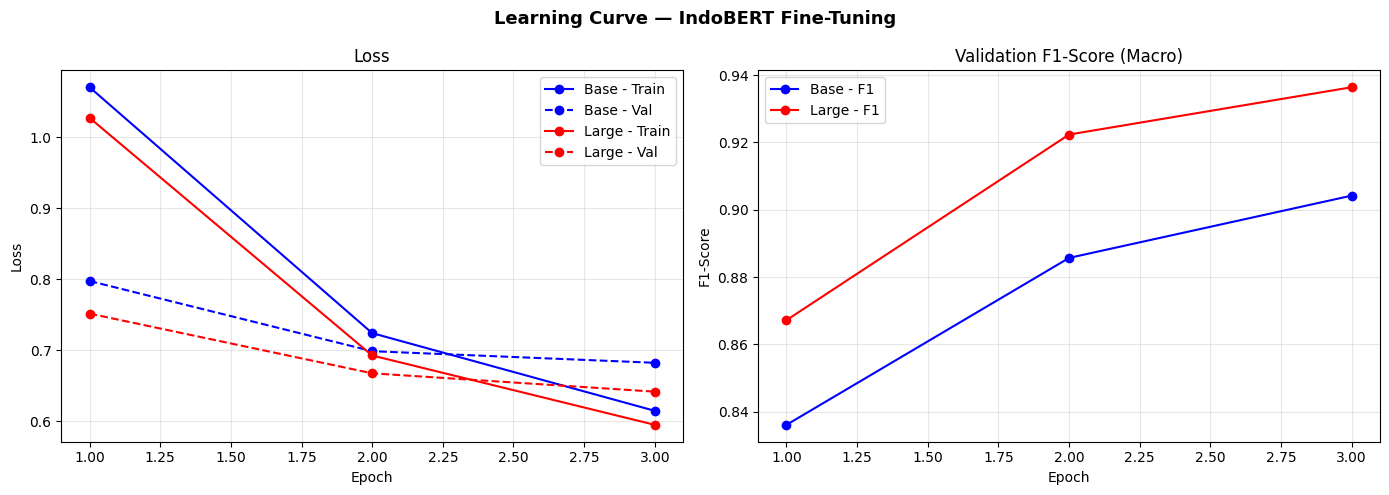

Learning curve disimpan


In [26]:
# Learning Curve IndoBERT
epochs_range = range(1, EPOCHS + 1)
fig, axes    = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve — IndoBERT Fine-Tuning', fontsize=13, fontweight='bold')

axes[0].plot(epochs_range, history_base['train_loss'], 'b-o',  label='Base - Train')
axes[0].plot(epochs_range, history_base['val_loss'],   'b--o', label='Base - Val')
if large_done:
    axes[0].plot(epochs_range, history_large['train_loss'], 'r-o',  label='Large - Train')
    axes[0].plot(epochs_range, history_large['val_loss'],   'r--o', label='Large - Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_base['val_f1'], 'b-o', label='Base - F1')  
if large_done:
    axes[1].plot(epochs_range, history_large['val_f1'], 'r-o', label='Large - F1')
axes[1].set_title('Validation F1-Score (Macro)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1-Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_PATH}/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Learning curve disimpan')

## 13. Simpan Model

In [27]:
# Simpan model terbaik berdasarkan F1
best_label  = df_results.iloc[0]['label']
is_base     = 'Base'   in best_label
is_large    = 'Large'  in best_label
is_baseline = 'TF-IDF' in best_label

# 1. Simpan TF-IDF + LR (sudah disimpan di sel baseline)
print('Model TF-IDF + LR:')
print(f'  {BL_TFIDF_PATH}    (TF-IDF vectorizer)')
print(f'  {BL_LR_ASPEK_PATH} (LR aspek)')

# 2. Simpan IndoBERT-Base
BASE_SAVE_DIR = f'{OUTPUT_PATH}/indobert_base_finetuned'
os.makedirs(BASE_SAVE_DIR, exist_ok=True)
tokenizer_base.save_pretrained(BASE_SAVE_DIR)
shutil.copy(path_base, f'{BASE_SAVE_DIR}/model_weights.pt')
print(f'\nIndoBERT-Base disimpan di: {BASE_SAVE_DIR}')

# 3. Simpan IndoBERT-Large
if large_done:
    LARGE_SAVE_DIR = f'{OUTPUT_PATH}/indobert_large_finetuned'
    os.makedirs(LARGE_SAVE_DIR, exist_ok=True)
    tokenizer_large.save_pretrained(LARGE_SAVE_DIR)
    shutil.copy(path_large, f'{LARGE_SAVE_DIR}/model_weights.pt')
    print(f'IndoBERT-Large disimpan di: {LARGE_SAVE_DIR}')

# Simpan model TERBAIK sebagai best_model_final
BEST_SAVE_DIR = f'{OUTPUT_PATH}/best_model_final'
os.makedirs(BEST_SAVE_DIR, exist_ok=True)

if is_baseline:
    shutil.copy(BL_TFIDF_PATH,    f'{BEST_SAVE_DIR}/tfidf.joblib')
    shutil.copy(BL_LR_ASPEK_PATH, f'{BEST_SAVE_DIR}/lr_aspek.joblib')
elif is_base:
    tokenizer_base.save_pretrained(BEST_SAVE_DIR)
    shutil.copy(path_base, f'{BEST_SAVE_DIR}/model_weights.pt')
elif is_large and large_done:
    tokenizer_large.save_pretrained(BEST_SAVE_DIR)
    shutil.copy(path_large, f'{BEST_SAVE_DIR}/model_weights.pt')

# Simpan konfigurasi model
model_config = {
    'best_model_label' : best_label,
    'model_type'       : 'baseline' if is_baseline else ('indobert_base' if is_base else 'indobert_large'),
    'model_name'       : (MODEL_BASE if is_base else MODEL_LARGE) if not is_baseline else 'TF-IDF+LR',
    'num_aspects'      : NUM_ASPECTS,
    'max_seq_length'   : MAX_SEQ_LENGTH,
    'aspect_labels'    : ASPECT_LABELS,
    'aspect_names'     : ASPECT_NAMES,
    'test_f1'          : float(df_results.iloc[0]['f1']),      
    'test_accuracy'    : float(df_results.iloc[0]['accuracy']), 
    'test_precision'   : float(df_results.iloc[0]['precision']),
    'test_recall'      : float(df_results.iloc[0]['recall']),   
}

with open(f'{BEST_SAVE_DIR}/model_config.json', 'w', encoding='utf-8') as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)

print(f'\n🏆 Best Model Final : {best_label}')
print(f'   F1 (Macro)      : {df_results.iloc[0]["f1"]:.4f}')
print(f'   Accuracy        : {df_results.iloc[0]["accuracy"]:.4f}')
print(f'   Disimpan di     : {BEST_SAVE_DIR}')

# Daftar semua output file
print('\nDaftar output file:')
for root, dirs, files in os.walk(OUTPUT_PATH):
    level      = root.replace(OUTPUT_PATH, '').count(os.sep)
    indent     = '  ' * level
    sub_indent = '  ' * (level + 1)
    if level < 2:
        print(f'{indent}{os.path.basename(root)}/')
        for file in sorted(files):
            size = os.path.getsize(os.path.join(root, file))
            print(f'{sub_indent}{file:<50} {size/1024:>8.1f} KB')

Model TF-IDF + LR:
  /kaggle/working/baseline_tfidf.joblib    (TF-IDF vectorizer)
  /kaggle/working/baseline_lr_aspek.joblib (LR aspek)

IndoBERT-Base disimpan di: /kaggle/working/indobert_base_finetuned
IndoBERT-Large disimpan di: /kaggle/working/indobert_large_finetuned

🏆 Best Model Final : IndoBERT-Large (Fine-tuned)
   F1 (Macro)      : 0.9275
   Accuracy        : 0.9465
   Disimpan di     : /kaggle/working/best_model_final

Daftar output file:
working/
  __notebook__.ipynb                                   1426.4 KB
  annotated_aspek_lainnya.csv                           765.1 KB
  annotated_reviews.csv                               28836.8 KB
  baseline_lr_aspek.joblib                              704.1 KB
  baseline_tfidf.joblib                                 387.6 KB
  best_indobert_base_finetuned.pt                    486220.5 KB
  best_indobert_large_finetuned.pt                   1309364.7 KB
  confmat_indobert-base_(fine-tuned).png                151.2 KB
  confmat_indobe

## 14. Inference Test

In [28]:
def predict_absa_bert(text, model, tokenizer):
    clean = preprocess_text(text)
    enc   = tokenizer(
        clean, max_length=MAX_SEQ_LENGTH,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    model.eval()
    with torch.no_grad():
        logits = model(enc['input_ids'].to(DEVICE), enc['attention_mask'].to(DEVICE))
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    return {
        'aspek'      : ASPECT_NAMES[int(probs.argmax())],
        'confidence' : float(probs.max()),
        'sentimen'   : 'negatif',
        'teks_bersih': clean,
    }


def predict_absa_baseline(text, tfidf_vec, lr_a):
    clean = preprocess_text(text)
    X     = tfidf_vec.transform([clean])
    pred  = lr_a.predict(X)[0]
    prob  = lr_a.predict_proba(X)[0].max()
    return {
        'aspek'      : ASPECT_NAMES[pred],
        'confidence' : float(prob),
        'sentimen'   : 'negatif',  
        'teks_bersih': clean,
    }


print('Fungsi inference siap')

Fungsi inference siap


In [29]:
# Jalankan Inference Test
test_inputs = [
    # Performa & Bug
    'Aplikasinya sangat lemot dan sering crash padahal hp saya bagus',
    'Server down mulu pas lagi mau bayar, nyebelin banget',
    'Aplikasi sering force close sendiri, tidak stabil banget',
    # Pembayaran & Transaksi
    'Bayar gagal terus tapi saldo sudah kepotong, minta refund susah banget',
    'Udah transfer tapi orderan ga keproses, uang gak balik juga sudah seminggu',
    'Dana hilang setelah checkout, tidak ada konfirmasi apapun',
    # UI/UX
    'Tampilannya membingungkan, susah cari menu yang saya mau',
    'Update terbaru malah bikin aplikasi jadi lebih ribet navigasinya',
    'Tombol checkout tidak kelihatan, layoutnya berantakan banget',
    # Layanan Pelanggan
    'CS tidak pernah balas chat, sudah 5 hari nunggu solusi tidak ada',
    'Admin cuek banget, komplain sudah 3 hari ga direspon sama sekali',
    'Customer service jawabnya cuma template, tidak ada solusi nyata',
    # Fitur Aplikasi
    'Fitur notifikasi sering error, pesanan datang tapi tidak ada notif sama sekali',
    'Gak ada fitur lacak pengiriman real time, beda sama kompetitor',
    'Fitur pencarian tidak akurat, barang yang dicari tidak muncul',
    # Pengiriman & Logistik
    'Kurir rekomendasi tokopedia selalu pilihkan JNE yang super lelet',
    'Paket sudah seminggu tidak bergerak, resi tidak diupdate sama sekali',
    'Estimasi 3 hari tapi sudah 2 minggu barang belum sampai, kurir nyasar',
    # Produk & Penjual
    'Barang yang datang beda sama foto di iklan, seller tidak mau retur',
    'Seller tidak responsif sama sekali, pesanan dibatalkan sepihak tanpa alasan',
    'Produk yang diterima cacat dan tidak sesuai deskripsi, penjual cuek',
    # Promosi & Voucher
    'Voucher diskon tidak bisa dipakai padahal belum expired',
    'Gratis ongkir selalu dibatalkan sistem kalau pakai kupon promo',
    'Flash sale bohong, barang habis tapi masih diiklankan promo besar-besaran',
]

# Tentukan model terbaik untuk inference
best_model_row   = df_results.iloc[0]
best_is_bert     = 'IndoBERT' in best_model_row['label']

if best_is_bert:
    best_model_infer     = model_base if 'Base' in best_model_row['label'] else model_large
    best_tokenizer_infer = tokenizer_base if 'Base' in best_model_row['label'] else tokenizer_large

print('=' * 80)
print(f'INFERENCE TEST — Menggunakan {best_model_row["label"]}')
print('=' * 80)

for i, text in enumerate(test_inputs, 1):
    if best_is_bert:
        r = predict_absa_bert(text, best_model_infer, best_tokenizer_infer)
    else:
        r = predict_absa_baseline(text, tfidf, lr_aspek)

    print(f'\n[{i}] Ulasan     : {text}')
    print(f'     Teks Bersih : {r["teks_bersih"]}')
    print(f'     Aspek       : {r["aspek"]} ({r["confidence"]:.1%})')
    print(f'     Sentimen    : {r["sentimen"]}')

print('\n' + '='*80)
print('Inference test selesai!')

INFERENCE TEST — Menggunakan IndoBERT-Large (Fine-tuned)

[1] Ulasan     : Aplikasinya sangat lemot dan sering crash padahal hp saya bagus
     Teks Bersih : aplikasinya sangat lambat dan sering crash padahal handphone saya bagus
     Aspek       : Performa & Bug (93.0%)
     Sentimen    : negatif

[2] Ulasan     : Server down mulu pas lagi mau bayar, nyebelin banget
     Teks Bersih : server down mulu pas lagi mau bayar nyebelin banget
     Aspek       : Performa & Bug (93.0%)
     Sentimen    : negatif

[3] Ulasan     : Aplikasi sering force close sendiri, tidak stabil banget
     Teks Bersih : aplikasi sering force close sendiri tidak stabil banget
     Aspek       : Performa & Bug (93.0%)
     Sentimen    : negatif

[4] Ulasan     : Bayar gagal terus tapi saldo sudah kepotong, minta refund susah banget
     Teks Bersih : bayar gagal terus tapi saldo sudah kepotong minta refund susah banget
     Aspek       : Pembayaran & Transaksi (92.6%)
     Sentimen    : negatif

[5] Ulasan     

In [30]:
# Perbandingan Inference semua model untuk 3 contoh
sample_texts = test_inputs[:3]

print('=' * 80)
print('PERBANDINGAN INFERENCE — Semua Model')
print('=' * 80)

for text in sample_texts:
    print(f'\nUlasan: "{text}"')
    print('-' * 60)

    # Baseline
    r_bl = predict_absa_baseline(text, tfidf, lr_aspek) 
    print(f'  [Baseline TF-IDF+LR]')
    print(f'    Aspek: {r_bl["aspek"]} ({r_bl["confidence"]:.1%})  '   
          f'Sentimen: {r_bl["sentimen"]}')

    # IndoBERT-Base
    r_base = predict_absa_bert(text, model_base, tokenizer_base)
    print(f'  [IndoBERT-Base]')
    print(f'    Aspek: {r_base["aspek"]} ({r_base["confidence"]:.1%})  ' 
          f'Sentimen: {r_base["sentimen"]}')

    # IndoBERT-Large
    if large_done:
        r_large = predict_absa_bert(text, model_large, tokenizer_large)
        print(f'  [IndoBERT-Large]')
        print(f'    Aspek: {r_large["aspek"]} ({r_large["confidence"]:.1%})  ' 
              f'Sentimen: {r_large["sentimen"]}')

print('\n' + '='*80)
print('Inference test selesai!')

PERBANDINGAN INFERENCE — Semua Model

Ulasan: "Aplikasinya sangat lemot dan sering crash padahal hp saya bagus"
------------------------------------------------------------
  [Baseline TF-IDF+LR]
    Aspek: Performa & Bug (98.7%)  Sentimen: negatif
  [IndoBERT-Base]
    Aspek: Performa & Bug (92.2%)  Sentimen: negatif
  [IndoBERT-Large]
    Aspek: Performa & Bug (93.0%)  Sentimen: negatif

Ulasan: "Server down mulu pas lagi mau bayar, nyebelin banget"
------------------------------------------------------------
  [Baseline TF-IDF+LR]
    Aspek: Performa & Bug (99.6%)  Sentimen: negatif
  [IndoBERT-Base]
    Aspek: Performa & Bug (91.9%)  Sentimen: negatif
  [IndoBERT-Large]
    Aspek: Performa & Bug (93.0%)  Sentimen: negatif

Ulasan: "Aplikasi sering force close sendiri, tidak stabil banget"
------------------------------------------------------------
  [Baseline TF-IDF+LR]
    Aspek: Performa & Bug (95.7%)  Sentimen: negatif
  [IndoBERT-Base]
    Aspek: Performa & Bug (92.2%)  Sentim